# ECG Dataset EDA

This notebook explores the processed ECG data that we use in the project.

It covers:
- Model 1: MIT-BIH R-peak detection data
- Model 2: PTB-XL disease classification data
- dataset shapes
- train/validation/test splits
- class distributions
- R-peak/window statistics
- beat/window statistics
- example ECG visualizations
- final long text summary


## 1. Setup


In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 5000)
plt.rcParams["figure.figsize"] = (10, 5)

# Find the project root by searching upward for data/processed
def find_project_root():
    current = Path.cwd().resolve()
    candidates = [current] + list(current.parents)
    for path in candidates:
        if (path / "data" / "processed").exists():
            return path
    return current


project_root = find_project_root()
data_dir = project_root / "data" / "processed"
model1_dir = data_dir / "model1"
model2_dir = data_dir / "model2"

## 2. Helper Functions

In [2]:
# Load split CSV files with train_idx, val_idx, and test_idx columns
def load_split_indices(path):
    splits = pd.read_csv(path)
    return {
        "train": splits["train_idx"].dropna().astype(int).to_numpy(),
        "val": splits["val_idx"].dropna().astype(int).to_numpy(),
        "test": splits["test_idx"].dropna().astype(int).to_numpy(),
    }


# Display the current matplotlib figure inline
def show_current_plot():
    plt.tight_layout()
    plt.show()


# Turn a count Series into a DataFrame with percentages
def add_percentages(counts):
    df = counts.rename("count").to_frame()
    df["percentage"] = (df["count"] / df["count"].sum() * 100).round(2)
    return df


# Create a table with split sizes and percentages
def split_sizes_table(splits):
    counts = pd.Series({name: len(idx) for name, idx in splits.items()}, name="count")
    return add_percentages(counts)


# Count class labels separately for train, validation, and test splits
def split_class_counts(meta_df, splits, label_column):
    rows = []
    for split_name, idx in splits.items():
        counts = meta_df.iloc[idx][label_column].value_counts().sort_index()
        for label, count in counts.items():
            rows.append({"split": split_name, "label": label, "count": int(count)})
    return pd.DataFrame(rows)


def plot_bar(series, title, xlabel, ylabel, figsize=(10, 5)):
    plt.figure(figsize=figsize)
    series.plot(kind="bar")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    show_current_plot()


def plot_hist(values, title, xlabel, ylabel, bins=30, figsize=(10, 5)):
    plt.figure(figsize=figsize)
    plt.hist(values, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    show_current_plot()


def plot_grouped_counts(count_df, title):
    pivot = count_df.pivot(index="label", columns="split", values="count").fillna(0)
    wanted_order = [col for col in ["train", "val", "test"] if col in pivot.columns]
    pivot = pivot[wanted_order]
    plt.figure(figsize=(10, 5))
    pivot.plot(kind="bar", ax=plt.gca())
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Samples")
    show_current_plot()
    return pivot


def display_text_block(text):
    """Display long plain-text summaries directly inside the notebook."""
    display(Markdown("```text\n" + text + "\n```"))

# 3. Model 1 EDA

Model 1 uses the MIT-BIH dataset to train an R-peak detector.

Input:

- `X_model1.npy`: ECG windows
- `y_model1.npy`: binary labels showing R-peak positions inside each window
- `model1_splits.csv`: train/validation/test indices

## 3.1. Load Model 1 Data

In [3]:
X1 = np.load(model1_dir / "X_model1.npy")
y1 = np.load(model1_dir / "y_model1.npy")
meta1 = pd.read_csv(model1_dir / "model1_metadata.csv")
splits1 = load_split_indices(model1_dir / "model1_splits.csv")

print("X_model1 shape:", X1.shape)
print("y_model1 shape:", y1.shape)
print("Metadata shape:", meta1.shape)
meta1.head()

X_model1 shape: (86592, 720)
y_model1 shape: (86592, 720)
Metadata shape: (86592, 4)


,record_name,start_idx,end_idx,num_peaks
0,100,0,720,3
1,100,360,1080,3
2,100,720,1440,2
3,100,1080,1800,2
4,100,1440,2160,3


## 3.2. Model 1 Basic Dataset Summary

In [4]:
model1_summary = pd.DataFrame({
    "Metric": [
        "Total windows/samples",
        "Window length",
        "Number of original records used",
        "Train samples",
        "Validation samples",
        "Test samples",
    ],
    "Value": [
        len(X1),
        X1.shape[1],
        meta1["record_name"].nunique(),
        len(splits1["train"]),
        len(splits1["val"]),
        len(splits1["test"]),
    ]
})

model1_summary

,Metric,Value
0,Total windows/samples,86592
1,Window length,720
2,Number of original records used,48
3,Train samples,60614
4,Validation samples,12989
5,Test samples,12989


## 3.3. Model 1 Split Sizes

This checks how much data is assigned to training, validation, and testing.

In [5]:
model1_split_sizes = split_sizes_table(splits1)
model1_split_sizes

,count,percentage
train,60614,70.0
val,12989,15.0
test,12989,15.0


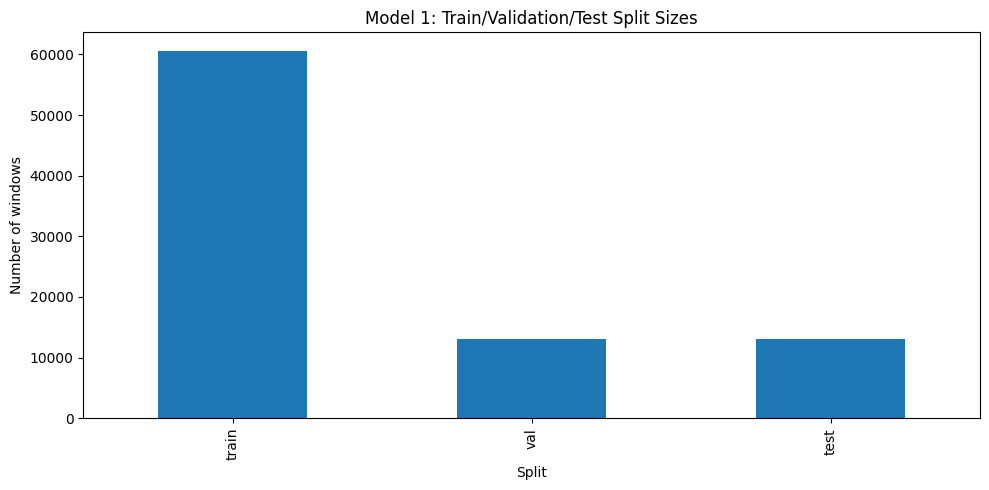

In [6]:
plot_bar(
    model1_split_sizes["count"],
    "Model 1: Train/Validation/Test Split Sizes",
    "Split",
    "Number of windows",
)

## 3.4. Windows per MIT-BIH Record

This checks whether every ECG record contributes a similar number of windows.

In [7]:
windows_per_record = meta1.groupby("record_name").size().sort_index()

windows_per_record.to_frame("windows")

,windows
record_name,
100,1804
101,1804
102,1804
103,1804
104,1804
105,1804
106,1804
107,1804
108,1804


## 3.5. R-Peaks per Window

Each `y_model1` row is a binary sequence. A value of `1` means there is an R-peak at that position inside the window.

This section checks how many R-peaks appear in each 720-sample window.

In [8]:
peaks_per_window = y1.sum(axis=1)
peaks_stats = pd.Series(peaks_per_window, name="r_peaks_per_window").describe()
peaks_stats

count    86592.000000
mean         2.526839
std          0.723144
min          0.000000
25%          2.000000
50%          3.000000
75%          3.000000
max          7.000000
Name: r_peaks_per_window, dtype: float64

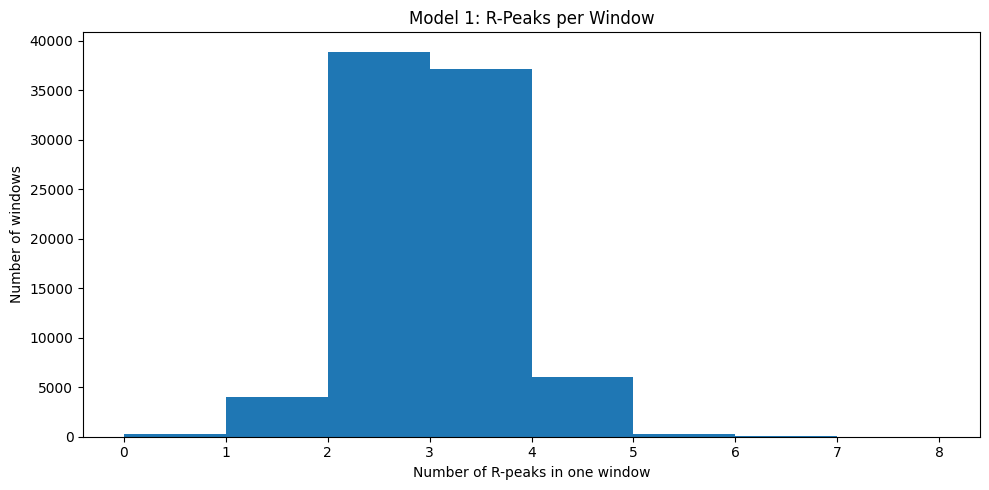

In [9]:
bins = range(int(peaks_per_window.max()) + 2)
plot_hist(
    peaks_per_window,
    "Model 1: R-Peaks per Window",
    "Number of R-peaks in one window",
    "Number of windows",
    bins=bins,
)

## 3.6. Model 1 Signal Value Distribution

The ECG windows were normalized. I expect a distribution centered around zero after z-score normalization and filtering.

In [10]:
# Sampling prevents the histogram from becoming unnecessarily large.
model1_sampled_values = X1.reshape(-1)[::100]
model1_signal_stats = pd.Series(model1_sampled_values, name="sampled_signal_values").describe()
model1_signal_stats

count    623463.000000
mean          0.000161
std           0.883619
min         -10.416809
25%          -0.356417
50%          -0.142856
75%           0.126384
max           9.170956
Name: sampled_signal_values, dtype: float64

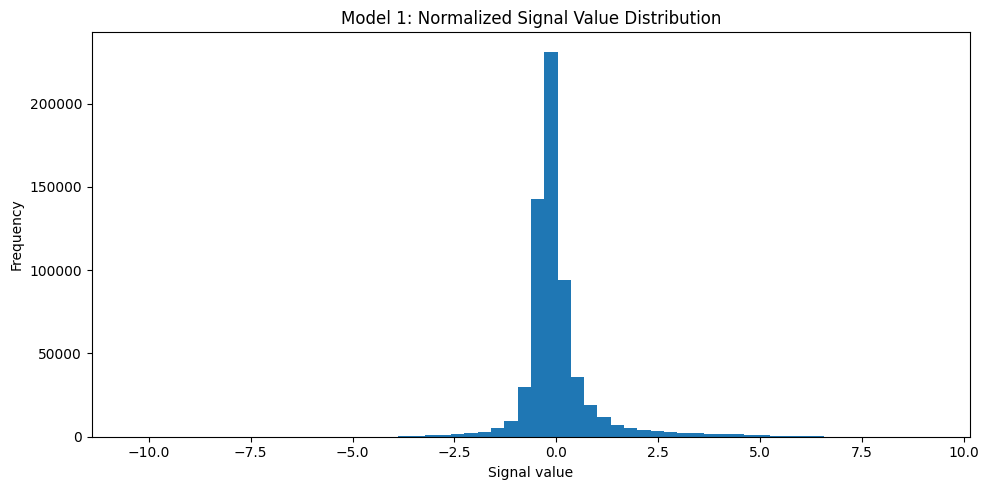

In [11]:
plot_hist(
    model1_sampled_values,
    "Model 1: Normalized Signal Value Distribution",
    "Signal value",
    "Frequency",
    bins=60,
)

## 3.7. Example ECG Windows with R-Peak Labels

The plot shows the first five ECG windows that contain at least one labeled R-peak.

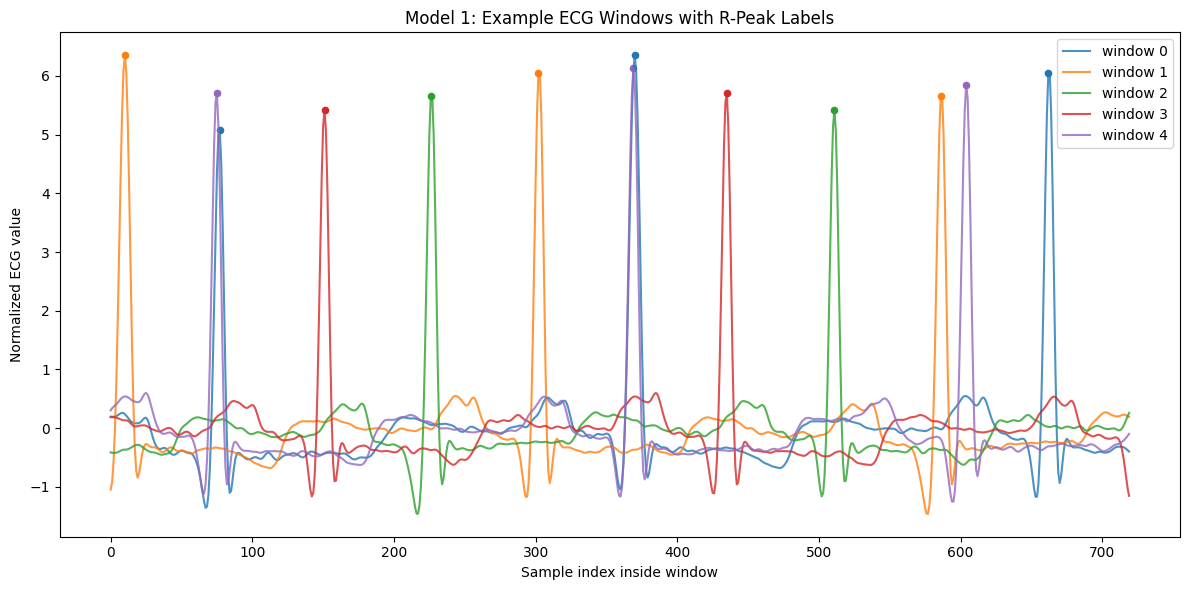

In [12]:
example_indices = np.where(peaks_per_window > 0)[0][:5] # first five valid windows with at least one R-peak label

plt.figure(figsize=(12, 6))
for idx in example_indices:
    signal = X1[idx]
    peak_positions = np.where(y1[idx] == 1)[0]
    plt.plot(signal, alpha=0.8, label=f"window {idx}")
    plt.scatter(peak_positions, signal[peak_positions], s=20)

plt.title("Model 1: Example ECG Windows with R-Peak Labels")
plt.xlabel("Sample index inside window")
plt.ylabel("Normalized ECG value")
plt.legend()
show_current_plot()

# 4. Model 2 EDA

Model 2 uses the PTB-XL dataset for disease classification.

Training files:

- `X_model2_beats.npy`: beat-level ECG segments
- `y_model2_beats.npy`: disease labels
- `model2_beat_splits.csv`: train/validation/test indices

The record-level files are also analyzed for comparison.

## 4.1. Load Model 2 Data

In [13]:
X2_records = np.load(model2_dir / "X_model2_records.npy", allow_pickle=True)
y2_records = np.load(model2_dir / "y_model2_records.npy", allow_pickle=True)

X2_beats = np.load(model2_dir / "X_model2_beats.npy")
y2_beats = np.load(model2_dir / "y_model2_beats.npy", allow_pickle=True)

record_meta2 = pd.read_csv(model2_dir / "model2_record_metadata.csv")
beat_meta2 = pd.read_csv(model2_dir / "model2_beat_metadata.csv")

record_splits2 = load_split_indices(model2_dir / "model2_record_splits.csv")
beat_splits2 = load_split_indices(model2_dir / "model2_beat_splits.csv")

print("X_model2_records shape:", X2_records.shape)
print("y_model2_records shape:", y2_records.shape)
print("X_model2_beats shape:", X2_beats.shape)
print("y_model2_beats shape:", y2_beats.shape)
print("Record metadata shape:", record_meta2.shape)
print("Beat metadata shape:", beat_meta2.shape)

X_model2_records shape: (16244, 1000)
y_model2_records shape: (16244,)
X_model2_beats shape: (320871, 70)
y_model2_beats shape: (320871,)
Record metadata shape: (16244, 4)
Beat metadata shape: (320871, 4)


## 4.2. Model 2 Basic Dataset Summary

In [14]:
model2_summary = pd.DataFrame({
    "Metric": [
        "Total record-level samples",
        "Record length",
        "Total beat-level samples",
        "Beat window length",
        "Train records",
        "Validation records",
        "Test records",
        "Train beats",
        "Validation beats",
        "Test beats",
    ],
    "Value": [
        len(X2_records),
        X2_records.shape[1],
        len(X2_beats),
        X2_beats.shape[1],
        len(record_splits2["train"]),
        len(record_splits2["val"]),
        len(record_splits2["test"]),
        len(beat_splits2["train"]),
        len(beat_splits2["val"]),
        len(beat_splits2["test"]),
    ]
})

model2_summary

,Metric,Value
0,Total record-level samples,16244
1,Record length,1000
2,Total beat-level samples,320871
3,Beat window length,70
4,Train records,12957
5,Validation records,1637
6,Test records,1650
7,Train beats,255905
8,Validation beats,32352
9,Test beats,32614


## 4.3. Model 2 Split Sizes

In [15]:
model2_record_split_sizes = split_sizes_table(record_splits2)
model2_beat_split_sizes = split_sizes_table(beat_splits2)


print("Record-level split sizes")
display(model2_record_split_sizes)

print("Beat-level split sizes")
display(model2_beat_split_sizes)

Record-level split sizes


,count,percentage
train,12957,79.76
val,1637,10.08
test,1650,10.16


Beat-level split sizes


,count,percentage
train,255905,79.75
val,32352,10.08
test,32614,10.16


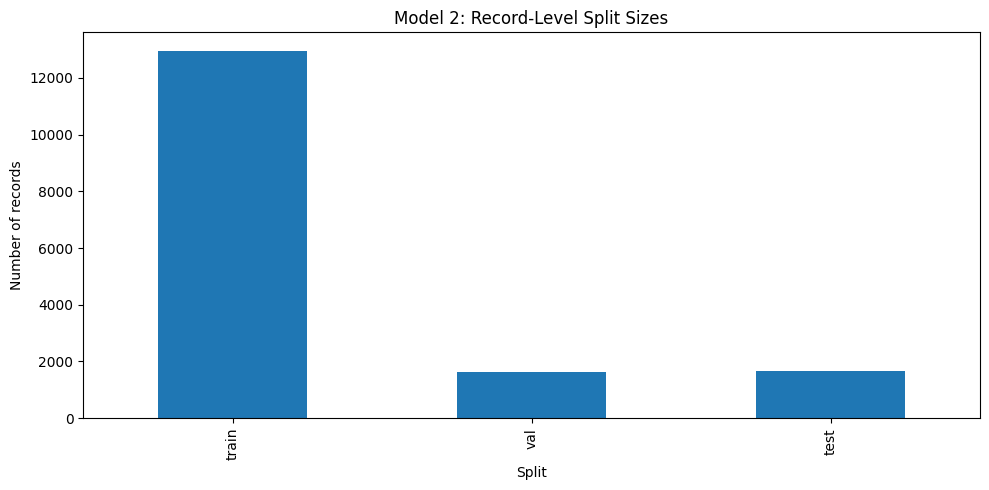

In [16]:
plot_bar(
    model2_record_split_sizes["count"],
    "Model 2: Record-Level Split Sizes",
    "Split",
    "Number of records",
)

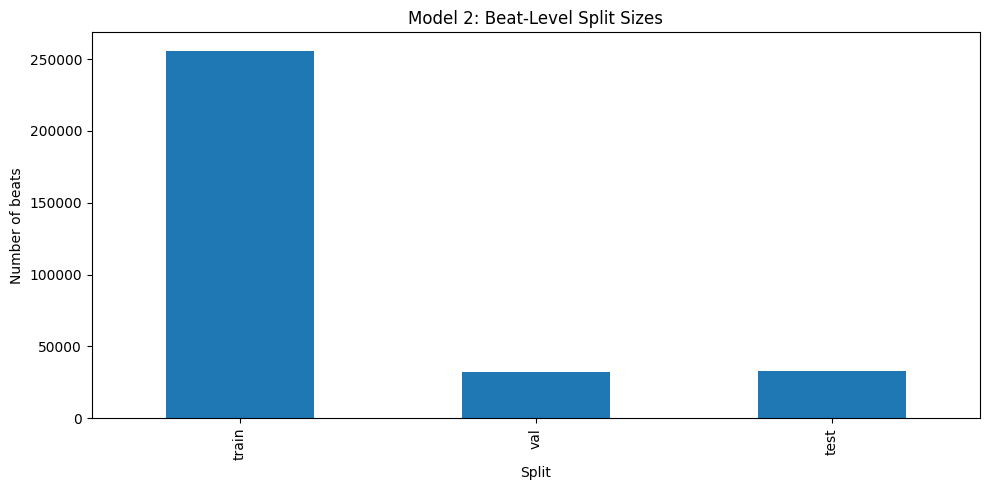

In [17]:
plot_bar(
    model2_beat_split_sizes["count"],
    "Model 2: Beat-Level Split Sizes",
    "Split",
    "Number of beats",
)

## 4.4. Record-Level and Beat-Level Class Distributions

This checks class imbalance. This is important because the classification model may learn the majority class more easily than the minority classes.

In [18]:
record_counts = record_meta2["label_code"].value_counts()
beat_counts = beat_meta2["label_code"].value_counts()

record_class_table = add_percentages(record_counts)
beat_class_table = add_percentages(beat_counts)


print("Record-level class distribution")
display(record_class_table)

print("Beat-level class distribution")
display(beat_class_table)

Record-level class distribution


,count,percentage
label_code,,
NORM,9069,55.83
MI,2532,15.59
STTC,2400,14.77
CD,1708,10.51
HYP,535,3.29


Beat-level class distribution


,count,percentage
label_code,,
NORM,179381,55.90
MI,50228,15.65
STTC,48659,15.16
CD,32618,10.17
HYP,9985,3.11


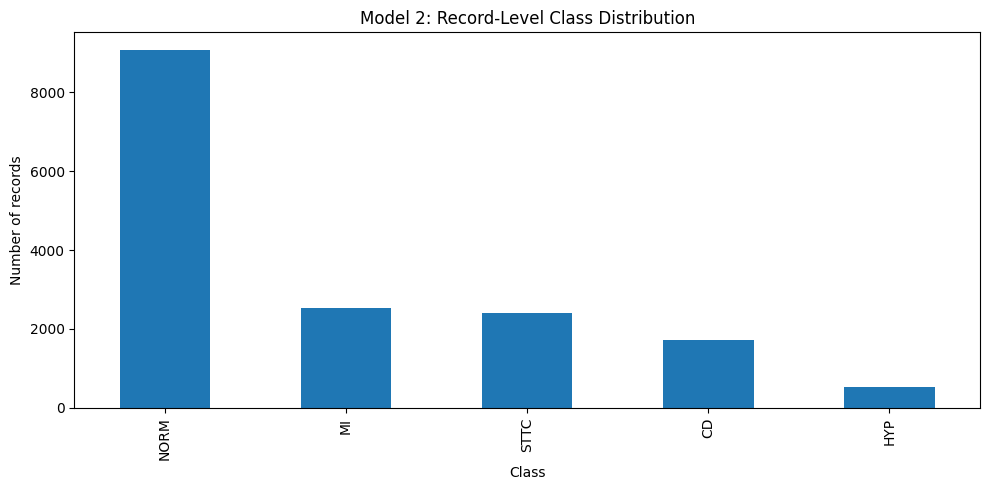

In [19]:
plot_bar(
    record_counts,
    "Model 2: Record-Level Class Distribution",
    "Class",
    "Number of records",
)

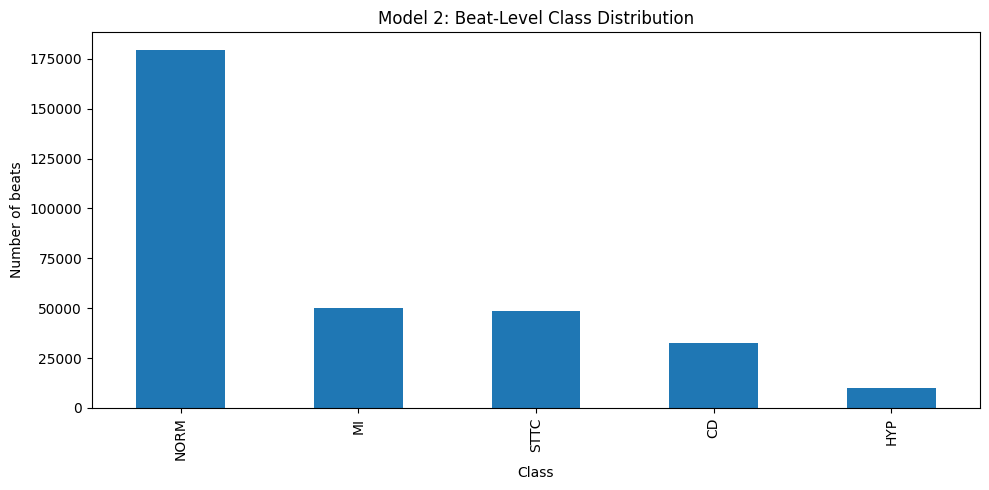

In [20]:
plot_bar(
    beat_counts,
    "Model 2: Beat-Level Class Distribution",
    "Class",
    "Number of beats",
)

## 4.5. Record-Level vs Beat-Level Class Distribution

This compares whether the beat-level extraction changes the class proportions compared with the original record-level data.

In [21]:
combined_counts = pd.DataFrame({
    "records": record_counts,
    "beats": beat_counts,
}).fillna(0)
combined_counts

,records,beats
label_code,,
NORM,9069,179381
MI,2532,50228
STTC,2400,48659
CD,1708,32618
HYP,535,9985


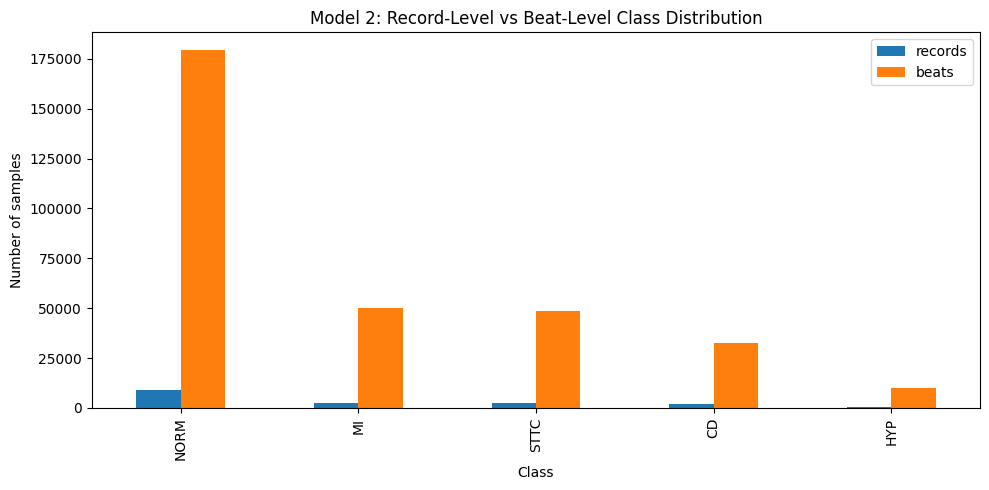

In [22]:
plt.figure(figsize=(10, 5))
combined_counts.plot(kind="bar", ax=plt.gca())
plt.title("Model 2: Record-Level vs Beat-Level Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of samples")
show_current_plot()

## 4.6. Class Counts by Split

This checks whether the train, validation, and test splits keep similar class proportions.

In [23]:
record_split_counts = split_class_counts(record_meta2, record_splits2, "label_code")
beat_split_counts = split_class_counts(beat_meta2, beat_splits2, "label_code")


print("Record-level class counts by split")
display(record_split_counts)

print("Beat-level class counts by split")
display(beat_split_counts)

Record-level class counts by split


,split,label,count
0,train,CD,1353
1,train,HYP,415
2,train,MI,2043
3,train,NORM,7243
4,train,STTC,1903
5,val,CD,171
6,val,HYP,64
7,val,MI,233
8,val,NORM,914
9,val,STTC,255


Beat-level class counts by split


,split,label,count
0,train,CD,25610
1,train,HYP,7756
2,train,MI,40245
3,train,NORM,143554
4,train,STTC,38740
5,val,CD,3354
6,val,HYP,1181
7,val,MI,4682
8,val,NORM,18041
9,val,STTC,5094


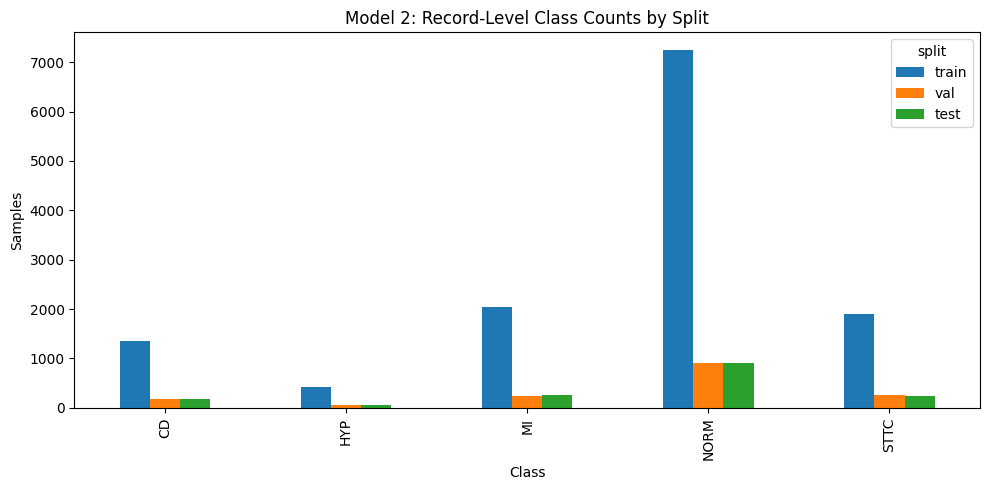

split,train,val,test
label,,,
CD,1353,171,184
HYP,415,64,56
MI,2043,233,256
NORM,7243,914,912
STTC,1903,255,242


In [24]:
record_split_pivot = plot_grouped_counts(
    record_split_counts,
    "Model 2: Record-Level Class Counts by Split"
)
record_split_pivot

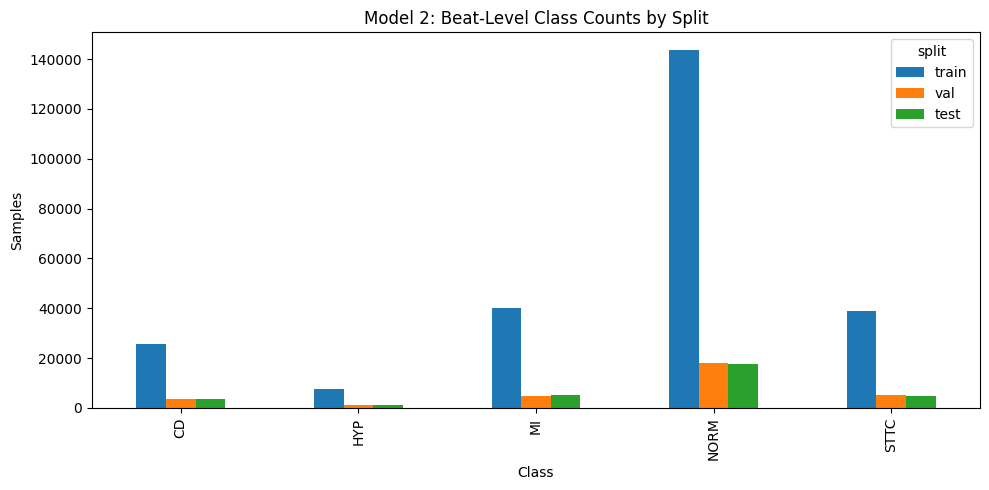

split,train,val,test
label,,,
CD,25610,3354,3654
HYP,7756,1181,1048
MI,40245,4682,5301
NORM,143554,18041,17786
STTC,38740,5094,4825


In [25]:
beat_split_pivot = plot_grouped_counts(
    beat_split_counts,
    "Model 2: Beat-Level Class Counts by Split"
)
beat_split_pivot

## 4.7. Beats per ECG Record

This shows how many heartbeat segments were extracted from each ECG record.

In [26]:
beats_per_record = beat_meta2.groupby("ecg_id").size()
beats_per_record_summary = beats_per_record.describe()
beats_per_record_summary

count    16244.000000
mean        19.753201
std          4.213457
min          8.000000
25%         17.000000
50%         20.000000
75%         23.000000
max         34.000000
dtype: float64

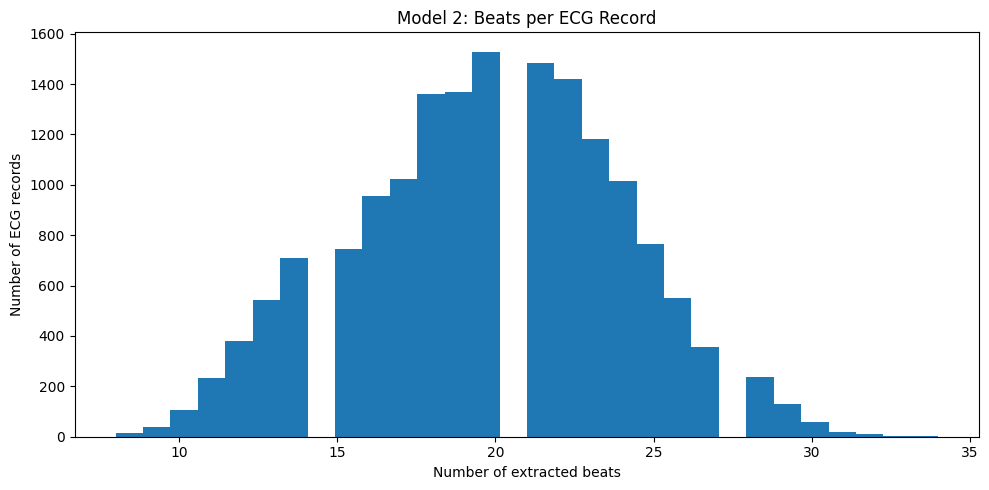

In [27]:
plot_hist(
    beats_per_record,
    "Model 2: Beats per ECG Record",
    "Number of extracted beats",
    "Number of ECG records",
    bins=30,
)

## 4.8. Beats per Record by Class

This checks whether some disease classes tend to produce more or fewer extracted beats per ECG record.

In [28]:
beats_per_record_df = beat_meta2.groupby("ecg_id").size().rename("beats_per_record").reset_index()
record_labels = record_meta2[["ecg_id", "label_code"]].drop_duplicates()
beats_per_record_df = beats_per_record_df.merge(record_labels, on="ecg_id", how="left")

beats_by_class_summary = beats_per_record_df.groupby("label_code")["beats_per_record"].describe()
beats_by_class_summary

,count,mean,std,min,25%,50%,75%,max
label_code,,,,,,,,
CD,1708.0,19.097190,4.797838,8.0,16.0,19.0,23.0,34.0
HYP,535.0,18.663551,4.074549,9.0,16.0,19.0,21.0,30.0
MI,2532.0,19.837283,4.176516,8.0,17.0,20.0,23.0,33.0
NORM,9069.0,19.779579,4.081795,8.0,17.0,20.0,23.0,32.0
STTC,2400.0,20.274583,4.230147,8.0,17.0,21.0,23.0,32.0


<Figure size 1000x500 with 0 Axes>

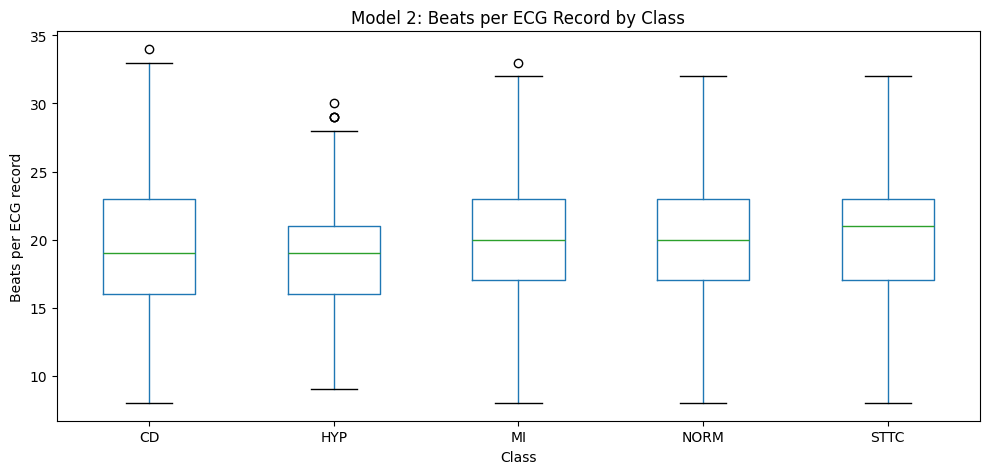

In [29]:
plt.figure(figsize=(10, 5))
beats_per_record_df.boxplot(column="beats_per_record", by="label_code", grid=False)
plt.title("Model 2: Beats per ECG Record by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Beats per ECG record")
show_current_plot()

## 4.9. Average Beat Shape by Class

This gives a visual comparison of the average heartbeat segment for each PTB-XL class.

To keep the notebook efficient, it uses up to 1000 beats per class.

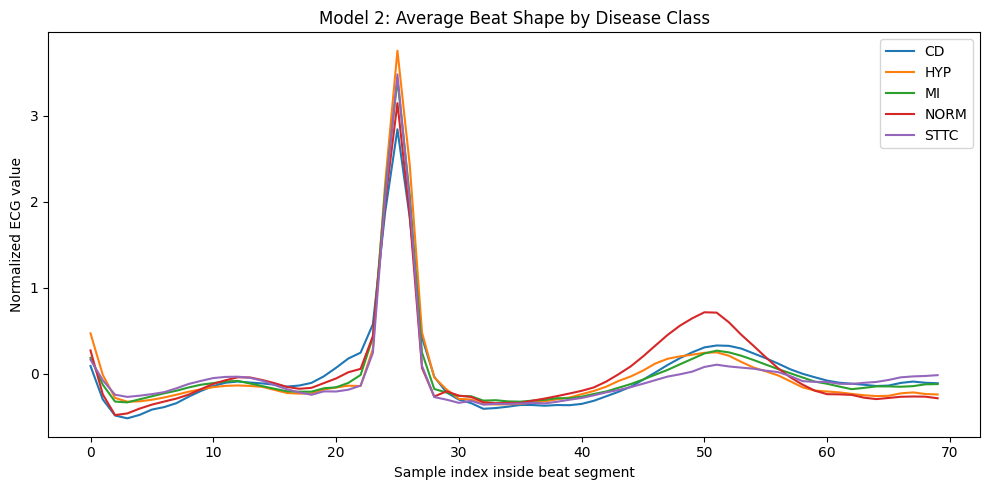

In [30]:
plt.figure(figsize=(10, 5))
mean_beats = []

for label in sorted(beat_meta2["label_code"].unique()):
    indices = beat_meta2.index[beat_meta2["label_code"] == label].to_numpy()
    selected = X2_beats[indices[: min(1000, len(indices))]]
    mean_beat = selected.mean(axis=0)
    mean_beats.append(pd.Series(mean_beat, name=label))
    plt.plot(mean_beat, label=label)

mean_beat_df = pd.concat(mean_beats, axis=1)

plt.title("Model 2: Average Beat Shape by Disease Class")
plt.xlabel("Sample index inside beat segment")
plt.ylabel("Normalized ECG value")
plt.legend()
show_current_plot()

## 4.10. Example Beat Segment from Each Class

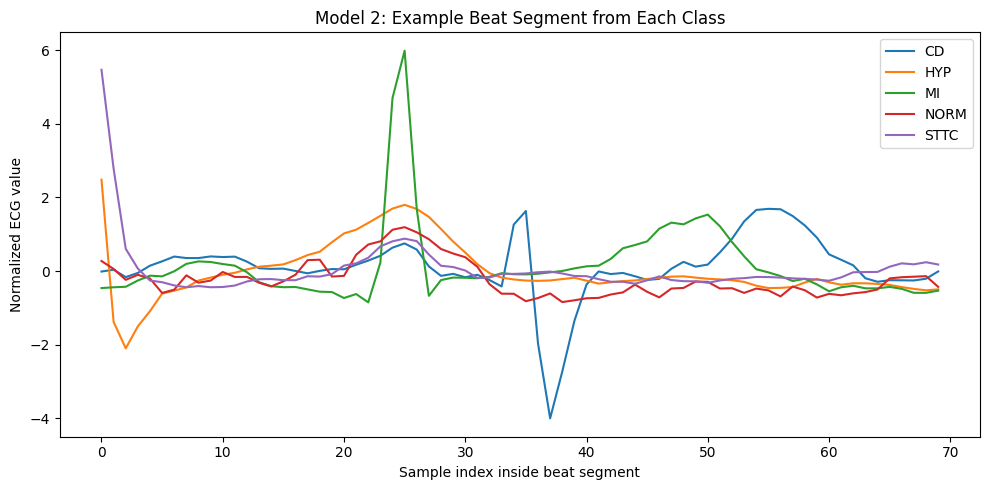

In [31]:
plt.figure(figsize=(10, 5))

for label in sorted(beat_meta2["label_code"].unique()):
    first_idx = beat_meta2.index[beat_meta2["label_code"] == label][0]
    plt.plot(X2_beats[first_idx], label=label)

plt.title("Model 2: Example Beat Segment from Each Class")
plt.xlabel("Sample index inside beat segment")
plt.ylabel("Normalized ECG value")
plt.legend()
show_current_plot()

## 4.11. Model 2 Beat Signal Value Distribution

This checks the distribution of normalized beat-segment values.

In [32]:
model2_sampled_values = X2_beats.reshape(-1)[::100]
model2_signal_stats = pd.Series(model2_sampled_values, name="sampled_beat_values").describe()
model2_signal_stats

count    224610.000000
mean         -0.039924
std           0.861620
min         -11.796500
25%          -0.435209
50%          -0.216933
75%           0.118102
max          11.238644
Name: sampled_beat_values, dtype: float64

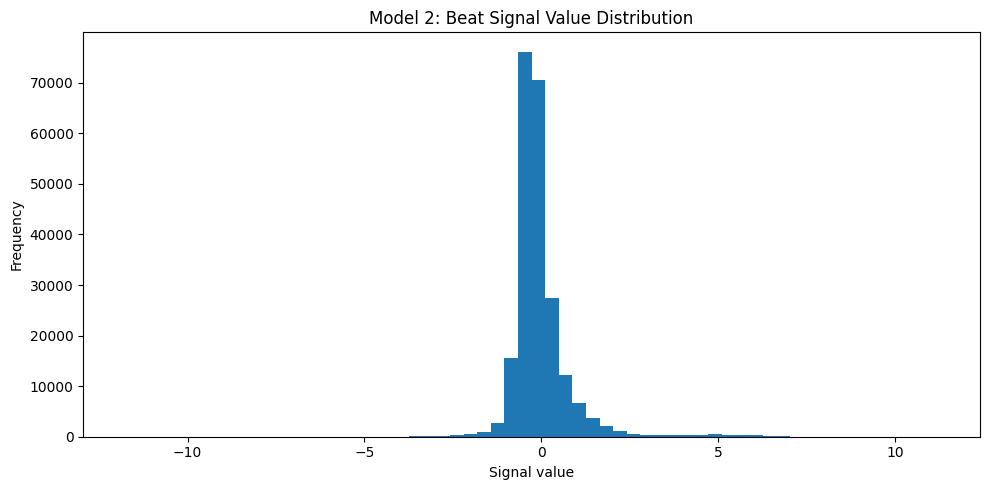

In [33]:
plot_hist(
    model2_sampled_values,
    "Model 2: Beat Signal Value Distribution",
    "Signal value",
    "Frequency",
    bins=60,
)

# 5. Final Text Summary

This cell displays the most important EDA results in one long text block directly here - inside the notebook.


In [34]:
summary_text = f"""
MODEL 1: MIT-BIH

X_model1 shape: {X1.shape}
y_model1 shape: {y1.shape}
Total windows/samples: {len(X1)}
Window length: {X1.shape[1]} samples
Number of original records used: {meta1['record_name'].nunique()}
Train samples: {len(splits1['train'])}
Validation samples: {len(splits1['val'])}
Test samples: {len(splits1['test'])}

Model 1 split sizes:
{model1_split_sizes.to_string()}

Windows per MIT-BIH record:
{windows_per_record.to_string()}

R-peaks per window descriptive statistics:
{peaks_stats.to_string()}

Model 1 sampled signal value statistics:
{model1_signal_stats.to_string()}

Interpretation for Model 1:
The MIT-BIH data was converted into fixed-length ECG windows for R-peak detection. Each input window has a matching binary label sequence where 1 marks an R-peak location. The windows-per-record table checks whether the original records contribute evenly to the dataset. The signal-value distribution checks whether normalization and filtering produced stable ECG values centered around zero.


MODEL 2: PTB-XL

X_model2_records shape: {X2_records.shape}
y_model2_records shape: {y2_records.shape}
Total record-level samples: {len(X2_records)}
Record length: {X2_records.shape[1]} samples

X_model2_beats shape: {X2_beats.shape}
y_model2_beats shape: {y2_beats.shape}
Total beat-level samples: {len(X2_beats)}
Beat window length: {X2_beats.shape[1]} samples

Train records: {len(record_splits2['train'])}
Validation records: {len(record_splits2['val'])}
Test records: {len(record_splits2['test'])}

Train beats: {len(beat_splits2['train'])}
Validation beats: {len(beat_splits2['val'])}
Test beats: {len(beat_splits2['test'])}

Model 2 record-level split sizes:
{model2_record_split_sizes.to_string()}

Model 2 beat-level split sizes:
{model2_beat_split_sizes.to_string()}

Record-level class distribution:
{record_class_table.to_string()}

Beat-level class distribution:
{beat_class_table.to_string()}

Record-level vs beat-level class counts:
{combined_counts.to_string()}

Record-level class counts by split:
{record_split_pivot.to_string()}

Beat-level class counts by split:
{beat_split_pivot.to_string()}

Beats per ECG record descriptive statistics:
{beats_per_record_summary.to_string()}

Beats per ECG record by class:
{beats_by_class_summary.to_string()}

Model 2 sampled beat signal value statistics:
{model2_signal_stats.to_string()}

Interpretation for Model 2:
The PTB-XL data was prepared for disease classification in two formats: record-level ECG samples and beat-level ECG segments. The beat-level version is the recommended input for the classification model because each sample focuses on a heartbeat-centered segment. The class-distribution tables show that the dataset is imbalanced, with NORM appearing much more often than some disease classes such as HYP. This is important for later model training because accuracy alone may hide weak performance on minority classes. The split-by-class tables check whether the train, validation, and test sets preserve a reasonable distribution of the five target classes. The beats-per-record statistics show how many beat segments were extracted from each ECG record.


Overall EDA Summary:

The processed files are ready to be used by the models. Model 1 has ECG windows and binary R-peak labels. Model 2 has record-level and beat-level disease-classification data. The EDA confirms the dataset sizes, split sizes, class distributions, signal distributions, peak/window statistics, and beat/record statistics. The most important issue for later training is class imbalance in Model 2, especially the smaller HYP class.
"""

display_text_block(summary_text)


```text

MODEL 1: MIT-BIH

X_model1 shape: (86592, 720)
y_model1 shape: (86592, 720)
Total windows/samples: 86592
Window length: 720 samples
Number of original records used: 48
Train samples: 60614
Validation samples: 12989
Test samples: 12989

Model 1 split sizes:
       count  percentage
train  60614        70.0
val    12989        15.0
test   12989        15.0

Windows per MIT-BIH record:
record_name
100    1804
101    1804
102    1804
103    1804
104    1804
105    1804
106    1804
107    1804
108    1804
109    1804
111    1804
112    1804
113    1804
114    1804
115    1804
116    1804
117    1804
118    1804
119    1804
121    1804
122    1804
123    1804
124    1804
200    1804
201    1804
202    1804
203    1804
205    1804
207    1804
208    1804
209    1804
210    1804
212    1804
213    1804
214    1804
215    1804
217    1804
219    1804
220    1804
221    1804
222    1804
223    1804
228    1804
230    1804
231    1804
232    1804
233    1804
234    1804

R-peaks per window descriptive statistics:
count    86592.000000
mean         2.526839
std          0.723144
min          0.000000
25%          2.000000
50%          3.000000
75%          3.000000
max          7.000000

Model 1 sampled signal value statistics:
count    623463.000000
mean          0.000161
std           0.883619
min         -10.416809
25%          -0.356417
50%          -0.142856
75%           0.126384
max           9.170956

Interpretation for Model 1:
The MIT-BIH data was converted into fixed-length ECG windows for R-peak detection. Each input window has a matching binary label sequence where 1 marks an R-peak location. The windows-per-record table checks whether the original records contribute evenly to the dataset. The signal-value distribution checks whether normalization and filtering produced stable ECG values centered around zero.


MODEL 2: PTB-XL

X_model2_records shape: (16244, 1000)
y_model2_records shape: (16244,)
Total record-level samples: 16244
Record length: 1000 samples

X_model2_beats shape: (320871, 70)
y_model2_beats shape: (320871,)
Total beat-level samples: 320871
Beat window length: 70 samples

Train records: 12957
Validation records: 1637
Test records: 1650

Train beats: 255905
Validation beats: 32352
Test beats: 32614

Model 2 record-level split sizes:
       count  percentage
train  12957       79.76
val     1637       10.08
test    1650       10.16

Model 2 beat-level split sizes:
        count  percentage
train  255905       79.75
val     32352       10.08
test    32614       10.16

Record-level class distribution:
            count  percentage
label_code                   
NORM         9069       55.83
MI           2532       15.59
STTC         2400       14.77
CD           1708       10.51
HYP           535        3.29

Beat-level class distribution:
             count  percentage
label_code                    
NORM        179381       55.90
MI           50228       15.65
STTC         48659       15.16
CD           32618       10.17
HYP           9985        3.11

Record-level vs beat-level class counts:
            records   beats
label_code                 
NORM           9069  179381
MI             2532   50228
STTC           2400   48659
CD             1708   32618
HYP             535    9985

Record-level class counts by split:
split  train  val  test
label                  
CD      1353  171   184
HYP      415   64    56
MI      2043  233   256
NORM    7243  914   912
STTC    1903  255   242

Beat-level class counts by split:
split   train    val   test
label                      
CD      25610   3354   3654
HYP      7756   1181   1048
MI      40245   4682   5301
NORM   143554  18041  17786
STTC    38740   5094   4825

Beats per ECG record descriptive statistics:
count    16244.000000
mean        19.753201
std          4.213457
min          8.000000
25%         17.000000
50%         20.000000
75%         23.000000
max         34.000000

Beats per ECG record by class:
             count       mean       std  min   25%   50%   75%   max
label_code                                                          
CD          1708.0  19.097190  4.797838  8.0  16.0  19.0  23.0  34.0
HYP          535.0  18.663551  4.074549  9.0  16.0  19.0  21.0  30.0
MI          2532.0  19.837283  4.176516  8.0  17.0  20.0  23.0  33.0
NORM        9069.0  19.779579  4.081795  8.0  17.0  20.0  23.0  32.0
STTC        2400.0  20.274583  4.230147  8.0  17.0  21.0  23.0  32.0

Model 2 sampled beat signal value statistics:
count    224610.000000
mean         -0.039924
std           0.861620
min         -11.796500
25%          -0.435209
50%          -0.216933
75%           0.118102
max          11.238644

Interpretation for Model 2:
The PTB-XL data was prepared for disease classification in two formats: record-level ECG samples and beat-level ECG segments. The beat-level version is the recommended input for the classification model because each sample focuses on a heartbeat-centered segment. The class-distribution tables show that the dataset is imbalanced, with NORM appearing much more often than some disease classes such as HYP. This is important for later model training because accuracy alone may hide weak performance on minority classes. The split-by-class tables check whether the train, validation, and test sets preserve a reasonable distribution of the five target classes. The beats-per-record statistics show how many beat segments were extracted from each ECG record.


Overall EDA Summary:

The processed files are ready to be used by the models. Model 1 has ECG windows and binary R-peak labels. Model 2 has record-level and beat-level disease-classification data. The EDA confirms the dataset sizes, split sizes, class distributions, signal distributions, peak/window statistics, and beat/record statistics. The most important issue for later training is class imbalance in Model 2, especially the smaller HYP class.

```

# 6. Final Notes/Insights

1. Model 1 has a large number of fixed-length ECG windows, each with binary R-peak position labels.
2. MIT-BIH records contribute a balanced number of windows, which helps avoid one record dominating the dataset.
3. Model 2 has both record-level and beat-level data, but the beat-level data is the recommended version for training.
4. The PTB-XL classes are imbalanced, especially because `NORM` has more samples than the disease classes.
5. The beat-level dataset is much larger than the record-level dataset, because multiple beats are extracted from each ECG record.